In [35]:
from google.colab import files

uploaded = files.upload()

Saving student-mat.csv to student-mat (1).csv


In [36]:
import pandas as pd

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename, sep=";")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

print("\nG3 values:")
print(df["G3"].head(10))

print("\nMissing G3 values:", df["G3"].isna().sum())

Shape: (395, 33)
Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,"GP;""F"";18;""U"";""GT3"";""A"";4;4;""at_home"";""teacher...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"GP;""F"";17;""U"";""GT3"";""T"";1;1;""at_home"";""other"";...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"GP;""F"";15;""U"";""LE3"";""T"";1;1;""at_home"";""other"";...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"GP;""F"";15;""U"";""GT3"";""T"";4;2;""health"";""services...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"GP;""F"";16;""U"";""GT3"";""T"";3;3;""other"";""other"";""h...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



G3 values:
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: G3, dtype: float64

Missing G3 values: 395


In [38]:
with open(filename, "r", encoding="utf-8-sig") as f:
    line1 = f.readline()
    line2 = f.readline()

print("HEADER:")
print(repr(line1))

print("\nFIRST DATA ROW:")
print(repr(line2))

HEADER:
'school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3\n'

FIRST DATA ROW:
'"GP;""F"";18;""U"";""GT3"";""A"";4;4;""at_home"";""teacher"";""course"";""mother"";2;2;0;""yes"";""no"";""no"";""no"";""yes"";""yes"";""no"";""no"";4;3;4;1;1;3;6;""5"";""6"";6"\n'


In [39]:
import pandas as pd
import csv

with open(filename, "r", encoding="utf-8-sig") as f:
    header = f.readline().strip().split(";")
    rows = []

    for line in f:
        line = line.strip()

        if line.startswith('"') and line.endswith('"'):
            line = line[1:-1]

        row = next(csv.reader([line], delimiter=";", quotechar='"'))
        rows.append(row)

df = pd.DataFrame(rows, columns=header)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nG3 values:")
print(df["G3"].head(10))

print("\nG3 missing:", df["G3"].isna().sum())

Shape: (395, 33)

First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,"F""""",18,"U""""","GT3""""","A""""",4,4,"at_home""""","teacher""""",...,4,3,4,1,1,3,6,"5""""","6""""",6
1,GP,"F""""",17,"U""""","GT3""""","T""""",1,1,"at_home""""","other""""",...,5,3,3,1,1,3,4,"5""""","5""""",6
2,GP,"F""""",15,"U""""","LE3""""","T""""",1,1,"at_home""""","other""""",...,4,3,2,2,3,3,10,"7""""","8""""",10
3,GP,"F""""",15,"U""""","GT3""""","T""""",4,2,"health""""","services""""",...,3,2,2,1,1,5,2,"15""""","14""""",15
4,GP,"F""""",16,"U""""","GT3""""","T""""",3,3,"other""""","other""""",...,4,3,2,1,2,5,4,"6""""","10""""",10



G3 values:
0     6
1     6
2    10
3    15
4    10
5    15
6    11
7     6
8    19
9    15
Name: G3, dtype: object

G3 missing: 0


In [40]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.replace('"', '', regex=False).str.strip()

for col in ["G1", "G2", "G3"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
display(df.head())

Shape: (395, 33)
Missing values: 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [41]:
X = df.drop(columns=["G3"])
y = df["G3"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (395, 32)
Target: (395,)


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (316, 32)
Testing: (79, 32)


In [43]:
import numpy as np

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['G1', 'G2']

Categorical Features:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [45]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

print("Linear Regression completed.")

Linear Regression completed.


In [46]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

print("Ridge Regression completed.")

Ridge Regression completed.


In [47]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.1, max_iter=10000))
])

lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

print("Lasso Regression completed.")

Lasso Regression completed.


In [48]:
from sklearn.linear_model import ElasticNet

elastic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000))
])

elastic_model.fit(X_train, y_train)
elastic_pred = elastic_model.predict(X_test)

print("Elastic Net completed.")

Elastic Net completed.


In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models_predictions = {
    "Linear Regression": linear_pred,
    "Ridge": ridge_pred,
    "Lasso": lasso_pred,
    "Elastic Net": elastic_pred
}

results = []

for name, predictions in models_predictions.items():
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

display(results_df)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.884520,6.214132,2.492816,0.696946
1,Ridge,1.796547,5.772823,2.402670,0.718468
2,Lasso,1.262362,3.827521,1.956405,0.813338
3,Elastic Net,1.383153,4.212286,2.052385,0.794573


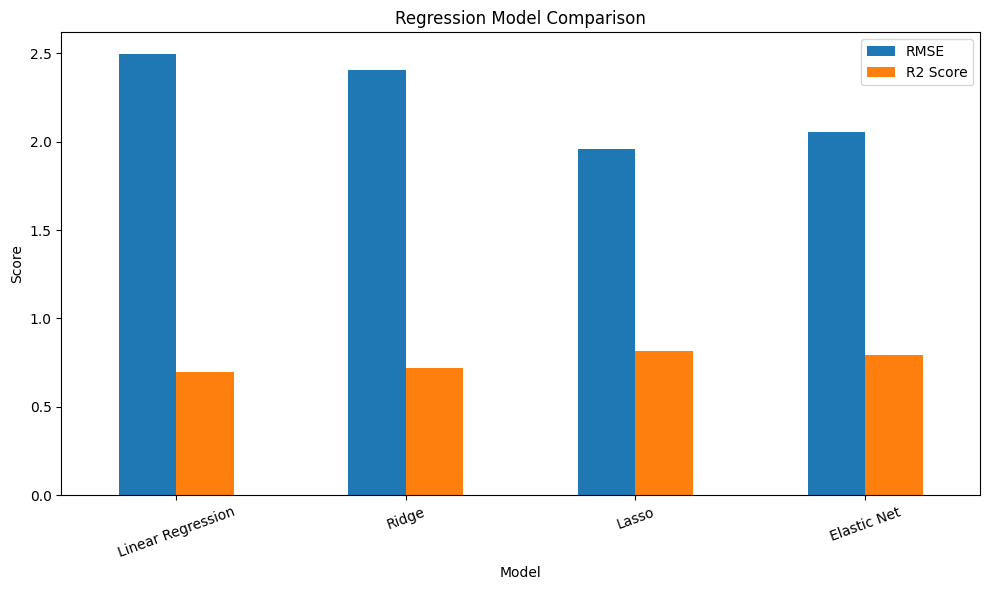

In [50]:
import matplotlib.pyplot as plt

results_plot = results_df.set_index("Model")

results_plot[["RMSE", "R2 Score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Regression Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

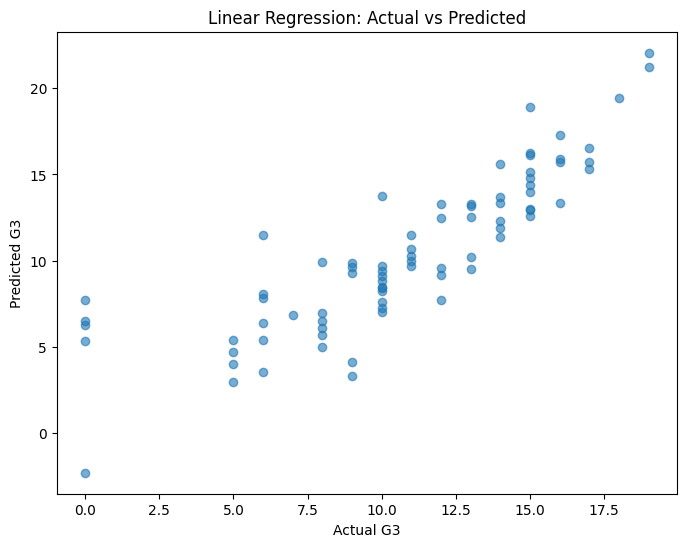

In [51]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, linear_pred, alpha=0.6)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

In [52]:
results_df.to_csv("session4_regression_results.csv", index=False)

print("Results saved successfully.")

Results saved successfully.


In [53]:
from google.colab import files

files.download("session4_regression_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>